# Day 21: Linear Regression from scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the dataset
url = 'https://raw.githubusercontent.com/Ankit152/Fish-Market/main/Fish.csv'
data = pd.read_csv(url)

In [3]:
data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [4]:
data.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [5]:
data.dtypes

Species     object
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

In [6]:
data.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [8]:
#Encode Categorical Species variable
data = pd.get_dummies(data, columns=['Species'], drop_first=True)

In [9]:
#Define Feature (X) and target Variable (y)
X = data.drop('Weight', axis=1).values
y = data['Weight'].values

In [10]:
#Split the data in to training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)


In [11]:
#Standardize the Feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#Add a column of ones to include the intercept term (bias)
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [14]:
#Initialize weights
theta = np.zeros(X_train.shape[1])

In [15]:
#Define Learning Rate and iterations
alpha = 0.01
iterations = 1000

In [16]:
#Implement the cost function
def compute_cost(X,y,theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/2*m) * np.sum(np.square(predictions - y))
    return cost

In [17]:
#Implement the gradient descent algorithm
def gradient_descent(X,y,theta, alpha, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        theta -= (alpha/m) * X.T.dot(errors)
        cost_history[i] = compute_cost(X,y,theta)

    return theta, cost_history

In [18]:
#Perform gradient descent to learn theta
theta, cost_history = gradient_descent(X_train, 
                                       y_train,
                                       theta,
                                       alpha,
                                       iterations)

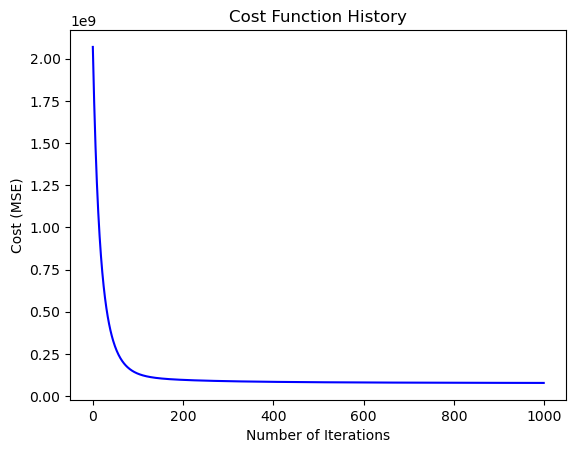

In [19]:
#Plot the cost function history
plt.plot(range(iterations), cost_history, color='blue')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost Function History')
plt.show()

In [25]:
#Evaluating the model
X_test = np.c_[np.ones(X_test.shape[0]), X_test]
predictions = X_test.dot(theta)

In [26]:
#Compute the Mean Absolute Error (MAE)
mae = np.mean(np.abs(predictions - y_test))
print(f'Mean Absoulte Error: {mae:.2f} grams')

Mean Absoulte Error: 61.53 grams


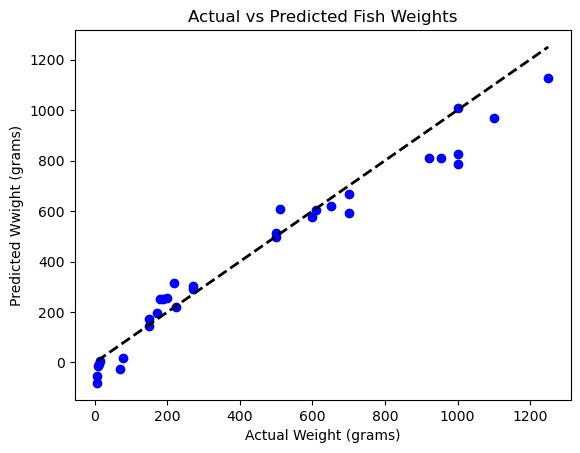

In [27]:
#Plot actual vs predicted weights
plt.scatter(y_test, predictions, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Weight (grams)')
plt.ylabel('Predicted Wwight (grams)')
plt.title('Actual vs Predicted Fish Weights')
plt.show()